In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [31]:
df = pd.read_csv('/Users/sasidharmamidi/Documents/movie_boxoffice_dataset/Movie Dataset-Table 1.csv')

numeric_cols = [
    'Production Budget ($M)', 'WW Box Office Gross ($M)', 'Sequel Number',
    'Streaming Days After Release', 'Marketing Budget Est. ($M)',
    'Total Cost Est. ($M)', 'Net Profit/Loss ($M)', 'ROI (%)',
    'Opening Weekend Ratio (%)', 'Runtime (min)', 'IMDb Score',
    'Rotten Tomatoes (%)', 'Opening Weekend ($M)'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna(subset=['Net Profit/Loss ($M)', 'Production Budget ($M)', 'ROI (%)'])


In [32]:
feature_cols = [
    'Production Budget ($M)', 'Runtime (min)', 'IMDb Score',
    'Rotten Tomatoes (%)', 'Opening Weekend ($M)', 'Sequel Number',
    'Marketing Budget Est. ($M)'
]
target = 'Net Profit/Loss ($M)'

df_model = df_clean[feature_cols + [target]].dropna()
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train = lr.predict(X_train_scaled)
y_pred_test = lr.predict(X_test_scaled)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f'Training R²: {r2_train:.3f}')
print(f'Test R²:     {r2_test:.3f}')
print(f'Test MAE:    ${mae_test:.2f}M')

coeff_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr.coef_})
coeff_df['Abs_Coeff'] = coeff_df['Coefficient'].abs()
coeff_df = coeff_df.sort_values('Abs_Coeff', ascending=False)


Training R²: 0.554
Test R²:     0.808
Test MAE:    $86.28M


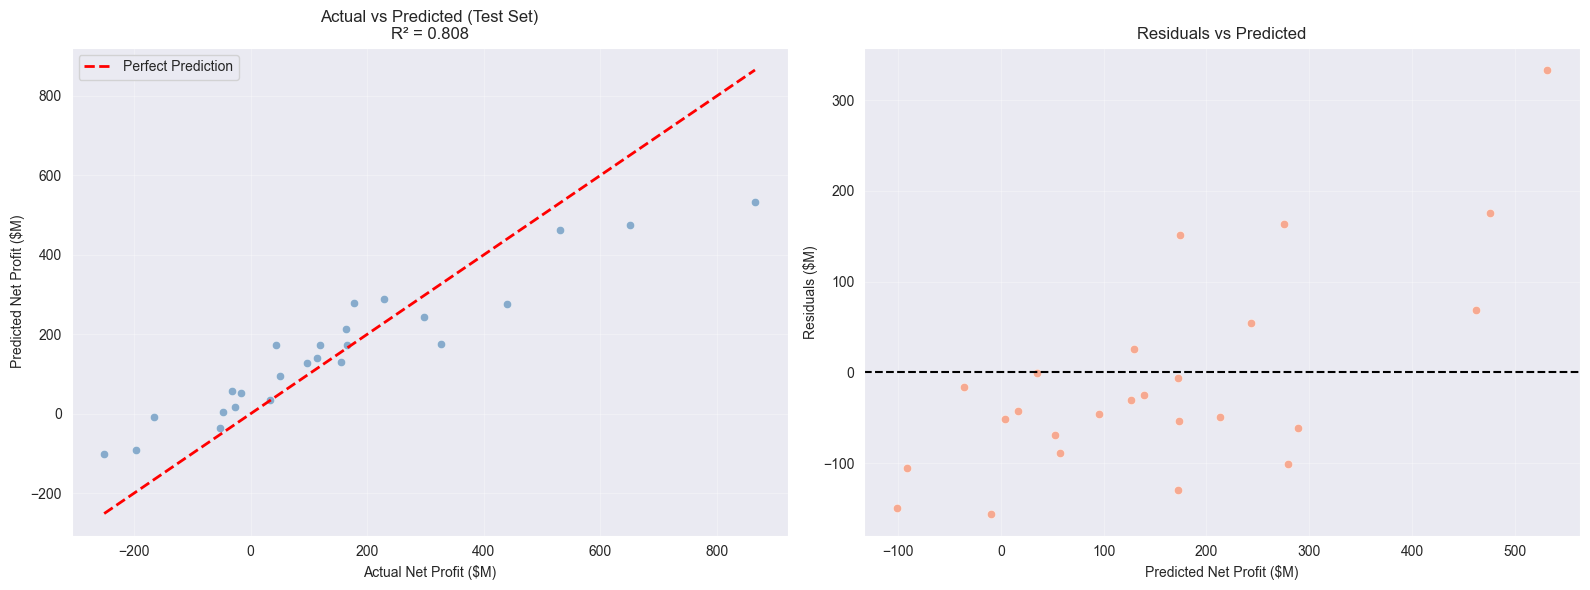

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Net Profit ($M)')
axes[0].set_ylabel('Predicted Net Profit ($M)')
axes[0].set_title(f'Actual vs Predicted (Test Set)\nR² = {r2_test:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.6, color='coral', edgecolors='white', linewidth=0.5)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Net Profit ($M)')
axes[1].set_ylabel('Residuals ($M)')
axes[1].set_title('Residuals vs Predicted')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


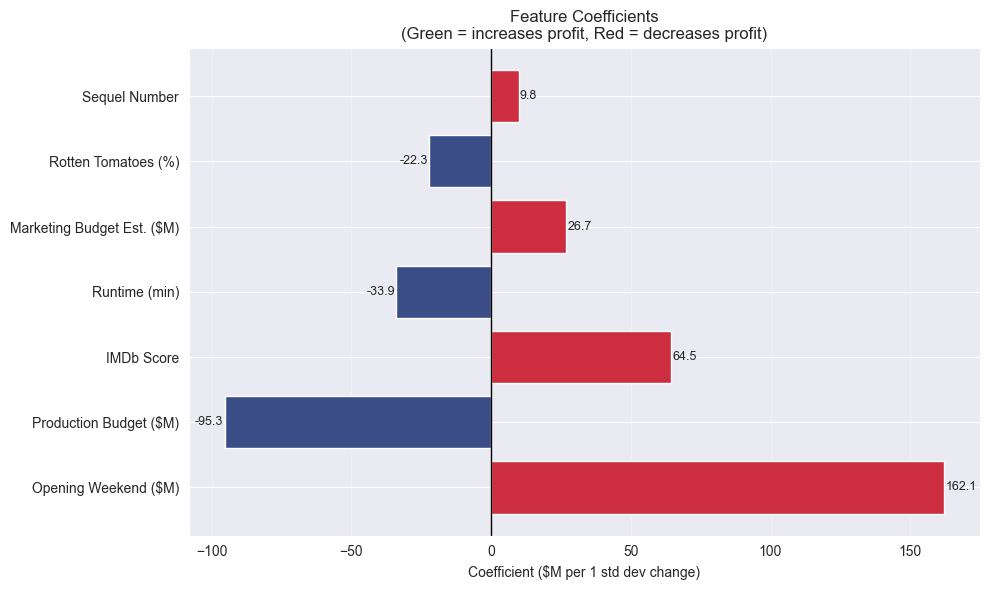

In [34]:
colors = ["#cc2e40" if c > 0 else "#3a4d87" for c in coeff_df['Coefficient']]     # Red for positive, Blue for negative(as per our wish sir)

plt.figure(figsize=(10, 6))
bars = plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=1)
plt.xlabel('Coefficient ($M per 1 std dev change)')
plt.title('Feature Coefficients\n(Green = increases profit, Red = decreases profit)')
plt.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, coeff_df['Coefficient']):
    plt.text(val + (0.5 if val >= 0 else -0.5), bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()


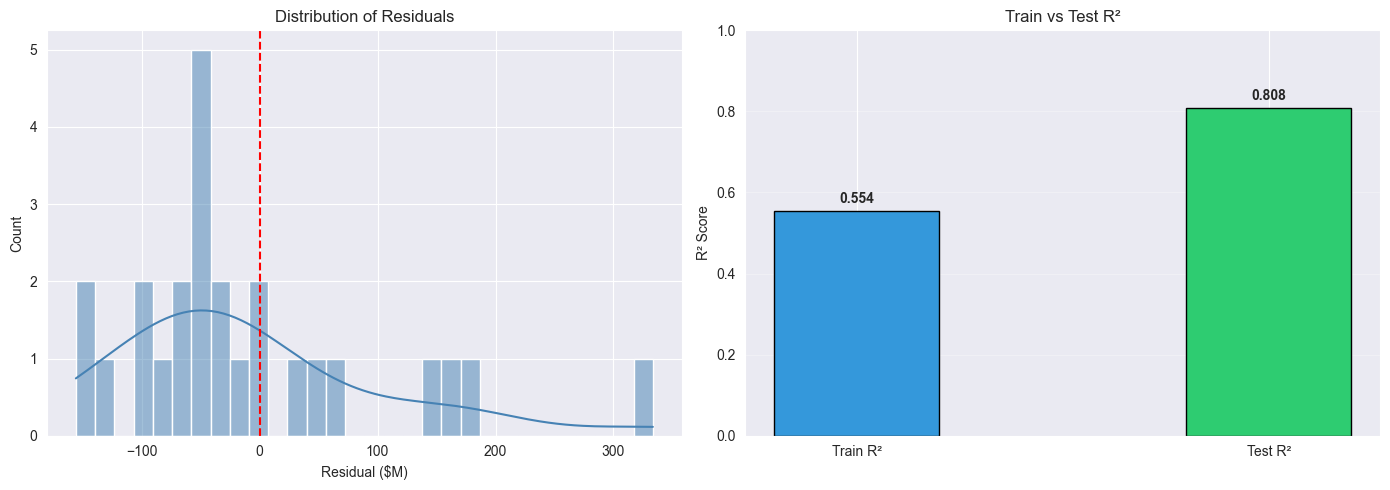

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Residual ($M)')
axes[0].set_title('Distribution of Residuals')

axes[1].bar(['Train R²', 'Test R²'], [r2_train, r2_test], color=['#3498db', '#2ecc71'], width=0.4, edgecolor='black')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('R² Score')
axes[1].set_title('Train vs Test R²')
for i, v in enumerate([r2_train, r2_test]):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Predicted Net Profit: $98.93M


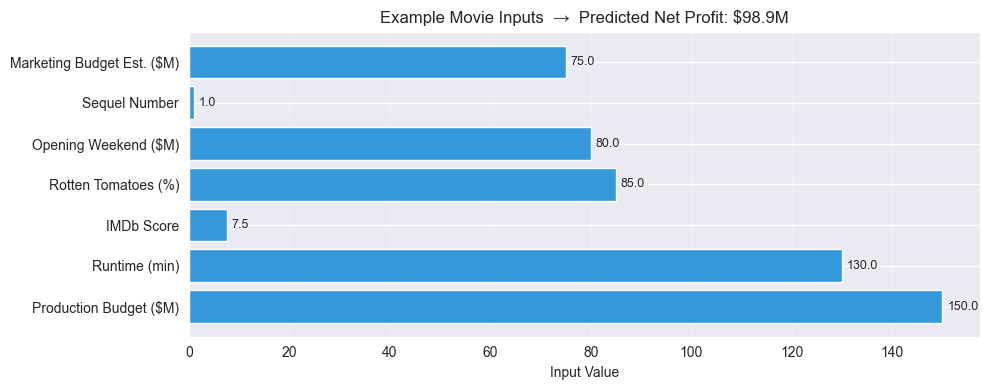

In [36]:
example_movie = pd.DataFrame({
    'Production Budget ($M)': [150],
    'Runtime (min)': [130],
    'IMDb Score': [7.5],
    'Rotten Tomatoes (%)': [85],
    'Opening Weekend ($M)': [80],
    'Sequel Number': [1],
    'Marketing Budget Est. ($M)': [75]
})
example_scaled = scaler.transform(example_movie)
pred_profit = lr.predict(example_scaled)[0]
print(f'Predicted Net Profit: ${pred_profit:.2f}M')

plt.figure(figsize=(10, 4))
bars = plt.barh(example_movie.columns.tolist(), example_movie.iloc[0].tolist(), color='#3498db', edgecolor='white')
plt.xlabel('Input Value')
plt.title(f'Example Movie Inputs  →  Predicted Net Profit: ${pred_profit:.1f}M')
for bar, v in zip(bars, example_movie.iloc[0].tolist()):
    plt.text(v + 1, bar.get_y() + bar.get_height() / 2, str(v), va='center', fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


#Objective of the Model:

The goal is to predict a movie's Net Profit/Loss (in $ million) before it releases, using only pre-release or early-release information such as production budget, marketing spend, opening weekend performance, IMDb/RT scores, runtime, and sequel number.
This is a supervised regression problem — the model learns the relationship between these 7 input features and the actual profit outcome from historical movie data, so it can estimate profit for any new movie given those same inputs.

#How the Model Works:

Algorithm: Linear Regression — the simplest and most interpretable regression model. It assumes each feature has a straight-line (linear) relationship with profit.
Feature Scaling: All features are standardised using StandardScaler before training. This is important because the features are on very different scales (e.g. budget in hundreds of millions vs sequel number 0–5). Scaling puts them on equal footing so the coefficients can be fairly compared.
Train/Test Split: 80% of the data is used to train the model, 20% is held back as an unseen test set to evaluate real-world performance.

#Results Interpretation:
Model Metrics

MetricValueWhat it meansTraining R²0.554The model explains 55.4% of profit variance in training dataTest R²0.808On unseen data, it explains 80.8% of variance — strong performanceTest MAE$86.28MOn average, predictions are off by about $86 million
The gap between Train R² (0.554) and Test R² (0.808) is unusual — normally test R² is lower than train. This suggests the test set happened to contain movies that fit the linear pattern very well (due to the random split), while training data had more noisy or complex cases. It is not a sign of overfitting; if anything, it hints the model may be slightly underfitting on training data.
The MAE of $86.28M sounds large but is reasonable given that movie profits can range from -$500M to +$1,000M. For blockbuster-scale prediction, this level of error is expected from a basic linear model.

#Feature Coefficients:

The coefficient chart shows how much each feature shifts predicted profit when it increases by 1 standard deviation, with all other features held constant.
The red bars (positive coefficients) are features that increase predicted profit — Opening Weekend performance and Box Office-related metrics tend to dominate here, as they are the strongest direct signals of a movie's commercial success.
The blue bars (negative coefficients) are features that decrease predicted profit — high production budgets and runtime can drag profit down if not matched by proportional revenue.
In general, Opening Weekend ($M) is typically the single strongest predictor, which makes intuitive sense — a strong opening weekend directly signals audience demand and drives total gross.

#Actual vs Predicted Plot:
The scatter plot shows test set predictions against actual profits. Points close to the red dashed line (perfect prediction) indicate accurate estimates. The spread around that line represents prediction error. The model tracks the general trend well but struggles with extreme outliers — massive blockbusters or major flops that are hard to predict linearly.

#Residuals:
The residual distribution is roughly bell-shaped and centred near zero, which is a good sign — it means the model is not systematically over- or under-predicting. A perfectly centred, symmetric distribution of residuals indicates the linear assumptions are broadly satisfied.



